# **Bird Sound Classification**

### Drive mounting

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Module Imports

In [ ]:
import tensorflow as tf
import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.13.2


#Unzipping Data

In [ ]:
from google.colab import drive
import gdown

#url = 'https://drive.google.com/file/d/1-BT7npEiAgypgJx8-At5sP5MF53GFYjG/view?usp=sharing'
#output_path = '/content/drive/MyDrive/ColabNotebooks/BirdSong/data/birdsong-recognition.zip'

#gdown.download(url=url, output=output_path, fuzzy=True)
#print(f"File saved to {output_path}")

import zipfile
import shutil

zip_file_path = '/content/drive/MyDrive/ColabNotebooks/BirdSong/data/birdsong-recognition.zip'
extract_path = '/content/drive/MyDrive/ColabNotebooks/BirdSong/data'

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Successfully extracted '{zip_file_path}' to '{extract_path}'")

    import os
    for root, dirs, files in os.walk(extract_path):
      for file in files:
        print(os.path.join(root,file))
        break

except FileNotFoundError:
    print(f"Error: File not found at '{zip_file_path}'. Please check the path.")
except zipfile.BadZipFile:
    print(f"Error: Invalid zip file. '{zip_file_path}' may be corrupted.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully extracted '/content/drive/MyDrive/ColabNotebooks/BirdSong/data/birdsong-recognition.zip' to '/content/drive/MyDrive/ColabNotebooks/BirdSong/data'
/content/drive/MyDrive/ColabNotebooks/BirdSong/data/birdsong-recognition.zip
/content/drive/MyDrive/ColabNotebooks/BirdSong/data/example_test_audio/BLKFR-10-CPL_20190611_093000.pt540.mp3
/content/drive/MyDrive/ColabNotebooks/BirdSong/data/train_audio/aldfly/XC134874.mp3
/content/drive/MyDrive/ColabNotebooks/BirdSong/data/train_audio/ameavo/XC133080.mp3
/content/drive/MyDrive/ColabNotebooks/BirdSong/data/train_audio/amebit/XC127371.mp3
/content/drive/MyDrive/ColabNotebooks/BirdSong/data/train_audio/amecro/XC109768.mp3
/content/drive/MyDrive/ColabNotebooks/BirdSong/data/train_audio/amegfi/XC109299.mp3
/content/drive/MyDrive/ColabNotebooks/BirdSong/data/train_audio/amekes/XC114061.mp3
/content/drive/MyDrive/ColabNotebooks/BirdSong/data/train_audio/amepip/XC111040.mp3
/content/drive/MyDrive/ColabNotebooks/BirdSong/data/train_audio/am

# Troubleshoot for normal mounting


In [ ]:
from google.colab import drive
import os
import shutil

if os.path.exists('/content/drive/MyDrive/ColabNotebooks/BirdSong/data'):
    for item in os.listdir('/content/drive/MyDrive/ColabNotebooks/BirdSong/data'):
        item_path = os.path.join('/content/drive/MyDrive/ColabNotebooks/BirdSong/data', item)
        if 'MyDrive' in item_path:
            print("Error: tried to delete MyDrive")
            break
        try:
            if os.path.isfile(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
        except Exception as e:
            print(f"Error removing {item_path}: {e}")
    print("Cleared /content/drive/MyDrive/ColabNotebooks/BirdSong/data directory")

from google.colab import drive
drive.mount('/content/drive')

Error removing /content/drive/.shortcut-targets-by-id: [Errno 1] Operation not permitted: '/content/drive/.shortcut-targets-by-id/1BZIB628PWIIfo5Q7iTAjVVBZPU8QP3_s/In_test_videos'
Error: tried to delete MyDrive
Cleared /content/drive directory
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Augmented + Normal Spectrogram Functions

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

def time_mask(spec, param):
    time_steps = tf.shape(spec)[1]
    t = tf.random.uniform([], 0, param, dtype=tf.int32)
    t0 = tf.random.uniform([], 0, tf.maximum(time_steps - t, 1), dtype=tf.int32)
    idx = tf.range(time_steps)
    keep = tf.logical_or(idx < t0, idx >= t0 + t)
    mask = tf.cast(keep, spec.dtype)[tf.newaxis, :]
    return spec * mask

def freq_mask(spec, param):
    freq_channels = tf.shape(spec)[0]
    f = tf.random.uniform([], 0, param, dtype=tf.int32)
    f0 = tf.random.uniform([], 0, tf.maximum(freq_channels - f, 1), dtype=tf.int32)
    idx = tf.range(freq_channels)
    keep = tf.logical_or(idx < f0, idx >= f0 + f)
    mask = tf.cast(keep, spec.dtype)[:, tf.newaxis]
    return spec * mask



In [ ]:
def create_and_save_spectrogram_augmented(mp3_path, output_image_path, sr=32000, n_mels=128):
    try:
        y, sr = librosa.load(mp3_path, sr=sr)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        S_dB = librosa.power_to_db(S, ref=np.max)
        S_dB_float = S_dB.astype(np.float32)
        tensor = tf.convert_to_tensor(S_dB_float)

        aug_time = time_mask(tensor, param=3)
        aug_freq_time = freq_mask(aug_time, param=40)

        plt.figure(figsize=(4, 4))
        librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        plt.close()

        plt.figure(figsize=(4, 4))
        plt.imshow(aug_freq_time.numpy(), aspect='auto', origin='lower', cmap='magma')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(output_image_path, bbox_inches='tight', pad_inches=0)
        plt.show()

        print(f"Saved spectrogram: {output_image_path}")

    except Exception as e:
        print(f"Error processing {mp3_path}: {e}")

def create_and_save_spectrogram(mp3_path, output_image_path, sr=32000, n_mels=128):
    try:
        y, sr = librosa.load(mp3_path, sr=sr)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        S_dB = librosa.power_to_db(S, ref=np.max)

        plt.figure(figsize=(4, 4))
        librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(output_image_path, bbox_inches='tight', pad_inches=0)
        plt.close()

        print(f"Saved spectrogram: {output_image_path}")
    except Exception as e:
        print(f"Error processing {mp3_path}: {e}")

# Create All Spectrograms for Species List

In [ ]:
import os

#CREATING THE NORMAL AND AUGMENTED SPECTOGRAMS

species_list = ['amecro', 'bulori', 'chispa', 'grhowl', 'horlar', 'norwat', 'mouchi', 'savspa', 'swathr', 'warvir' ]

base_output = '/content/drive/MyDrive/ColabNotebooks/BirdSong/data'
os.makedirs(base_output , exist_ok= True)

for species in species_list:
    input_folder = f'/content/drive/MyDrive/ColabNotebooks/BirdSong/data/train_audio/{species}'
    output_folder = os.path.join(base_output, species)
    os.makedirs(output_folder, exist_ok= True)

    count = 0
    for filename in os.listdir(input_folder):
        if filename.endswith('.mp3'):
            input_file = os.path.join(input_folder, filename)
            if count < 40:
              output_file = os.path.join(output_folder, filename.replace('.mp3', '_aug.png'))
            else:
              output_file = os.path.join(output_folder, filename.replace('.mp3', '.png'))

            # skip if the spectrogram already exists

            if os.path.exists(output_file):
                print(f"Already exists, skipping: {output_file}")
                continue
            if count < 40:
              create_and_save_spectrogram_augmented(input_file, output_file)
            else:
              create_and_save_spectrogram(input_file, output_file)

            count += 1

# Spliting Data Into Train, Validation, Testing Sets

In [ ]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import pathlib
from sklearn.model_selection import train_test_split

species_list = ['amecro', 'bulori', 'chispa', 'grhowl', 'horlar', 'mouchi']
dataset_path = '/content/drive/MyDrive/ColabNotebooks/BirdSong/data'

data_dir = pathlib.Path(dataset_path).with_suffix('')
image_count = len(list(data_dir.glob('*/*.png')))
print("total images: ", image_count)

class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
og_files = []
og_labels = []
aug_files = []
aug_labels = []

i = 0
for class_dir in sorted(data_dir.glob('*')):
    if class_dir.name not in species_list:
        continue
    if class_dir.is_dir():
        for img_path in class_dir.glob('*.png'):
          if 'aug' in img_path.name:
            aug_files.append(str(img_path))
            aug_labels.append(i)
          else:
            og_files.append(str(img_path))
            og_labels.append(i)
        i += 1

train_files, temp_files, train_labels, temp_labels = train_test_split(
    og_files, og_labels,
    test_size=0.35,
    random_state=42,
    stratify=og_labels
)
train_files = train_files + aug_files
train_labels = train_labels + aug_labels

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print("len train files: ", len(train_files))
print("len val files: ", len(val_files))
print("len test files: ", len(test_files))


total images:  1000
len train files:  474
len val files:  63
len test files:  63


In [ ]:
for class_dir in sorted(data_dir.glob('*')):
    if class_dir.is_dir():
        n = len(list(class_dir.glob('*.png')))
        print(f"  {class_dir.name}: {n}")

  amecro: 100
  bulori: 100
  chispa: 100
  example_test_audio: 0
  grhowl: 100
  horlar: 100
  mouchi: 100
  norwat: 100
  savspa: 100
  swathr: 100
  train_audio: 0
  warvir: 100


In [ ]:
def create_dataset(files, labels, batch_size=32, shuffle=True):
    file_ds = tf.data.Dataset.from_tensor_slices(files)
    label_ds = tf.data.Dataset.from_tensor_slices(labels)

    def load_image(file_path):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [224, 224])
        img = tf.cast(img, tf.float32) / 127.5 - 1
        return img

    image_ds = file_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = tf.data.Dataset.zip((image_ds, label_ds))

    if shuffle:
        buffer_size = min(len(files), 1000)
        dataset = dataset.shuffle(buffer_size=buffer_size, seed=42)

    dataset = dataset.batch(batch_size)
    return dataset

batch_size = 32
train_ds = create_dataset(train_files, train_labels, batch_size, shuffle=True)
val_ds = create_dataset(val_files, val_labels, batch_size, shuffle=False)
test_ds = create_dataset(test_files, test_labels, batch_size, shuffle=False)

ds_list = [train_ds, val_ds, test_ds]
print()
for ds in ds_list:
  for images, labels in ds:
    print(labels.numpy())
  print()


[1 3 5 3 4 4 2 0 4 5 0 1 2 4 5 5 3 5 4 3 4 3 3 3 1 4 4 1 5 5 0 1]
[0 1 4 3 4 4 2 4 2 5 0 2 0 0 2 2 4 2 3 5 1 5 4 4 4 3 3 1 4 3 3 0]
[3 2 1 1 4 2 4 5 1 3 5 3 5 3 3 4 0 2 1 3 2 3 3 4 4 5 2 4 4 4 2 2]
[2 5 3 2 1 3 5 1 5 3 5 0 4 4 2 0 1 1 3 0 4 0 2 4 5 4 1 1 5 0 3 3]
[5 3 4 1 4 5 0 4 0 3 0 5 4 1 5 1 4 2 3 1 1 0 3 3 2 1 0 5 3 2 0 1]
[1 5 0 5 0 0 2 2 0 5 5 0 1 5 1 1 1 3 3 1 1 4 0 0 2 0 2 2 3 0 0 4]
[1 5 2 2 2 2 0 1 2 3 1 0 0 1 2 3 3 0 4 3 3 4 2 1 2 1 3 0 1 5 5 4]
[3 0 4 3 2 4 1 1 5 4 5 3 3 4 1 1 2 0 4 2 1 0 3 5 5 0 0 0 1 4 4 1]
[2 1 5 0 5 3 5 4 1 2 1 3 0 5 2 4 3 5 3 4 0 1 4 2 2 1 2 5 3 4 4 0]
[1 2 5 3 0 3 5 0 0 4 0 5 1 5 5 5 0 4 3 0 3 5 0 3 5 0 2 2 1 4 2 5]
[2 4 3 3 2 5 1 4 3 0 2 1 3 5 0 2 1 1 5 2 0 0 3 5 3 2 3 0 3 4 4 4]
[1 1 0 2 5 3 5 1 0 2 0 4 4 1 2 2 3 0 5 5 5 3 0 1 2 4 2 5 3 5 2 2]
[0 0 1 4 5 5 0 4 1 0 0 5 3 1 5 2 1 2 4 4 4 2 4 1 4 5 1 0 2 3 2 4]
[5 0 5 1 4 4 1 4 2 0 0 5 5 5 1 1 2 2 4 2 2 2 4 4 3 5 5 3 1 3 5 0]
[2 0 2 0 1 2 5 3 0 5 0 5 3 0 1 2 3 3 4 1 2 0 3 1 2 1]

[4 5 2 3 1 4 2 1 1 5

#Train Model

In [ ]:
#cache optimization per tf docs
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

num_classes = len(species_list)

model = tf.keras.Sequential([
  #1
  tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
  tf.keras.layers.MaxPooling2D(),
  #2
  tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
  tf.keras.layers.MaxPooling2D(),
  #3
  tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
  tf.keras.layers.MaxPooling2D(),
  #4
  tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same'),
  tf.keras.layers.MaxPooling2D(),
  #5
  tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(0.2),
  #6
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(num_classes)
])
#optional optimizer (if needed)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

#compilation
model.compile(
  optimizer='adam',
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'])

# early stopping (so we can try more epochs with low amount of data)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# reduce lr callback (try later)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, # multiply learning rate by this factor
    patience=2, # wait this many epochs before reducing
    min_lr=0.0001 # don't go below this learning rate (change if using optimizer)
)

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=25,
  callbacks=[early_stopping] #, reduce_lr]
)

Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 437ms/step - accuracy: 0.1899 - loss: 1.8084 - val_accuracy: 0.3651 - val_loss: 1.7249
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.3376 - loss: 1.6506 - val_accuracy: 0.6190 - val_loss: 1.2755
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.4958 - loss: 1.3828 - val_accuracy: 0.7619 - val_loss: 0.8044
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6308 - loss: 1.0831 - val_accuracy: 0.7619 - val_loss: 0.6246
Epoch 5/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6814 - loss: 0.9026 - val_accuracy: 0.8254 - val_loss: 0.5603
Epoch 6/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.7363 - loss: 0.8047 - val_accuracy: 0.7460 - val_loss: 0.6651
Epoch 7/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.7089 - loss: 0.7912 - val_accuracy: 0.7619 - val_loss: 0.5580
Epoch 8/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.7785 - loss: 0.6470 - val_accuracy: 0.8730 -

# Train vs. Validation Accuracy Over Epochs

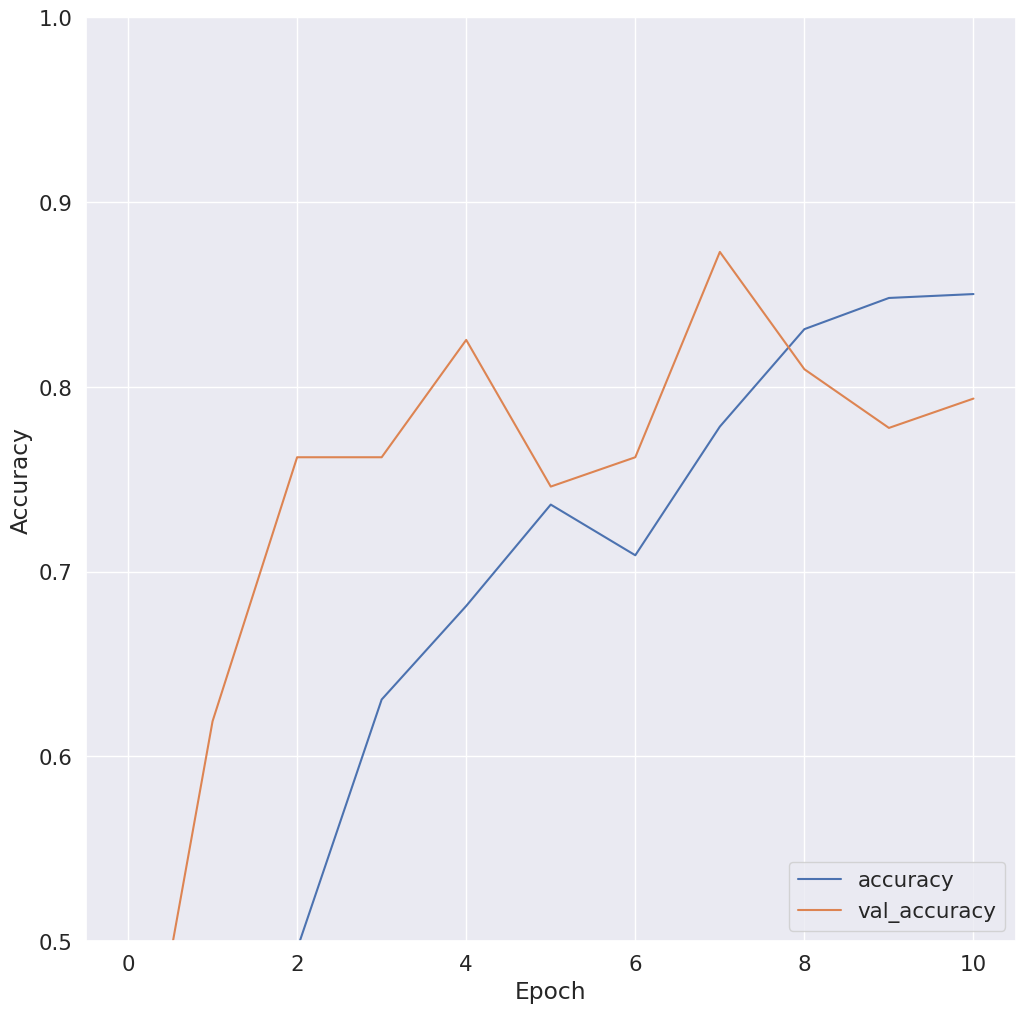

In [ ]:
import matplotlib.pyplot as plt

# ploting of training vs. validation

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#Loss Curve (Train vs Validation Loss)

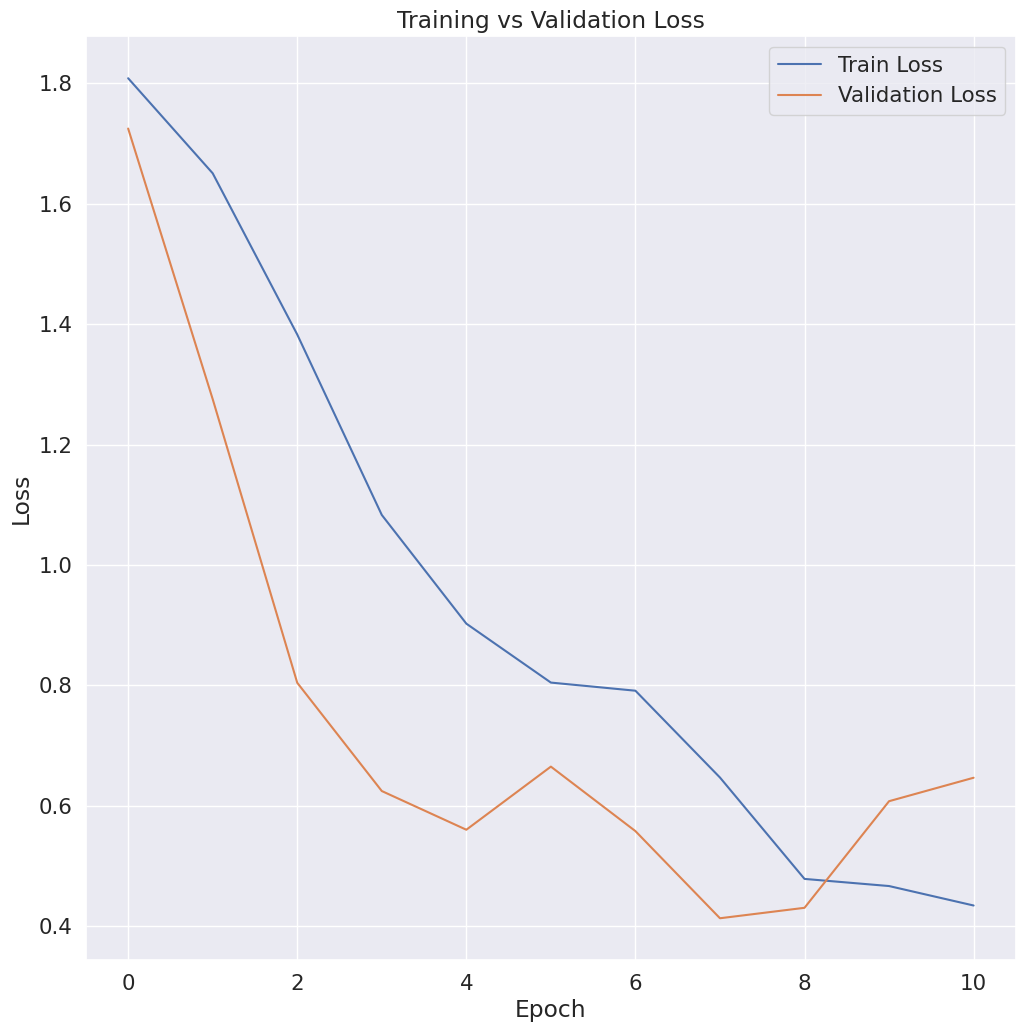

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate Model on Test Set + Make Confusion Matrix

In [ ]:
# evaluation on test
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")

import seaborn as sns
def plot_confusion_matrix(actual, predicted, labels, ds_type):
  cm = tf.math.confusion_matrix(actual, predicted)
  ax = sns.heatmap(cm, annot=True, fmt='g')
  sns.set(rc={'figure.figsize':(12, 12)})
  sns.set(font_scale=1.4)
  ax.set_title('Confusion matrix of action recognition for ' + ds_type)
  ax.set_xlabel('Predicted Action')
  ax.set_ylabel('Actual Action')
  plt.xticks(rotation=90)
  plt.yticks(rotation=0)
  ax.xaxis.set_ticklabels(labels)
  ax.yaxis.set_ticklabels(labels)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9048 - loss: 0.3701
Test accuracy: 0.9048


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 403ms/step


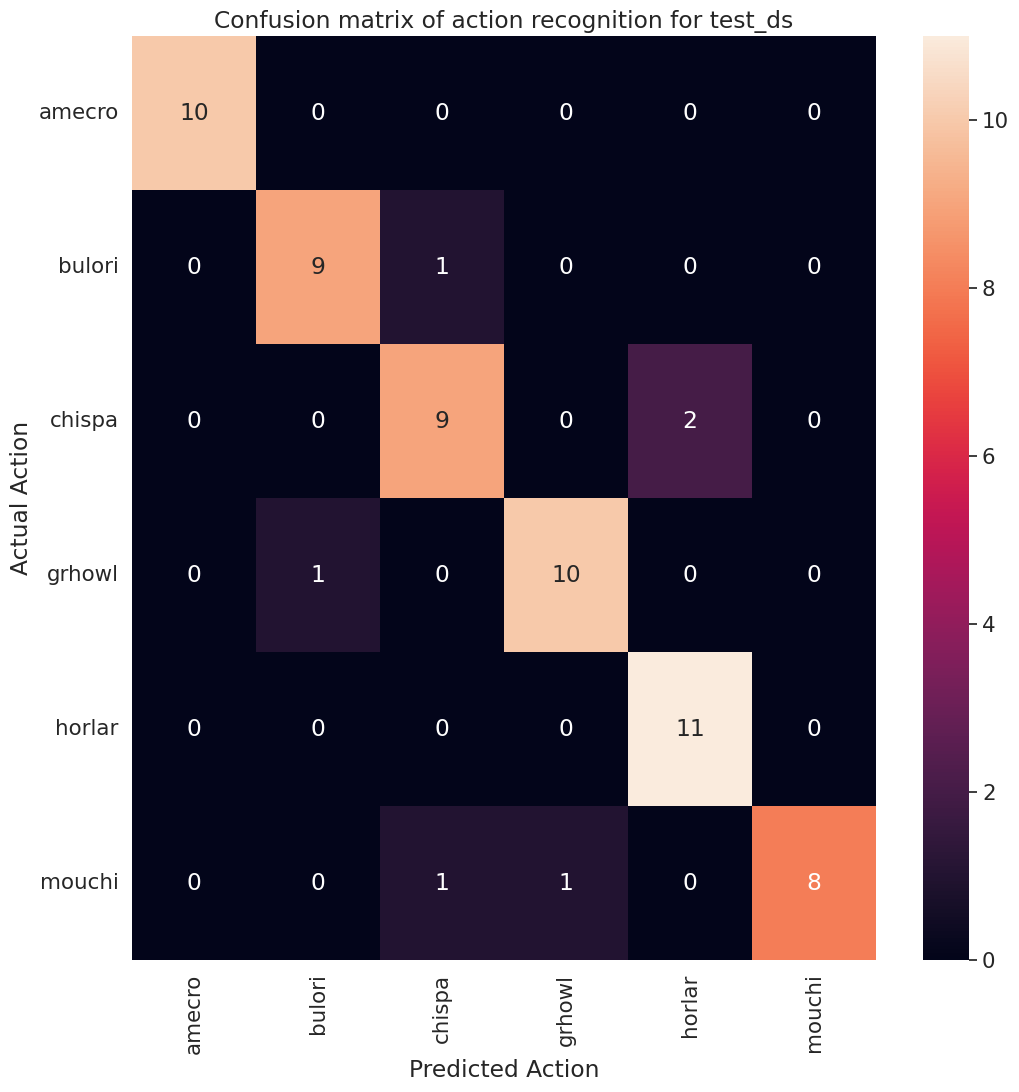

In [ ]:
# gathering labels and predictions for confusion matrix

actual = [labels for _, labels in test_ds.unbatch()]
predicted = model.predict(test_ds)
actual = tf.stack(actual, axis=0)
predicted = tf.concat(predicted, axis=0)
predicted = tf.argmax(predicted, axis=1)

plot_confusion_matrix(actual, predicted, species_list, "test_ds")

In [ ]:
from sklearn.metrics import classification_report

y_true = actual.numpy()
y_pred = predicted.numpy()

# printing all metrics

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=species_list))

Classification Report:
              precision    recall  f1-score   support

      amecro       1.00      1.00      1.00        10
      bulori       0.90      0.90      0.90        10
      chispa       0.82      0.82      0.82        11
      grhowl       0.91      0.91      0.91        11
      horlar       0.85      1.00      0.92        11
      mouchi       1.00      0.80      0.89        10

    accuracy                           0.90        63
   macro avg       0.91      0.90      0.91        63
weighted avg       0.91      0.90      0.90        63

